In [1]:
%pwd
%cd /home/jovyan/work/results/Cell/
%pwd

/home/jovyan/work/results/Cell


'/home/jovyan/work/results/Cell'

In [2]:
import os
import tempfile

import matplotlib.pyplot as plt
import scanpy as sc
import scvi
import seaborn as sns
import torch
import gc

In [3]:
scvi.settings.seed = 0
print("Last run with scvi-tools version:", scvi.__version__)

Seed set to 0


Last run with scvi-tools version: 1.1.5


In [4]:
sc.set_figure_params(figsize=(6, 6), frameon=False)
sns.set_theme()
torch.set_float32_matmul_precision("high")

%config InlineBackend.print_figure_kwargs={"facecolor": "w"}
%config InlineBackend.figure_format="retina"

In [5]:
# has to be raw counts
adata = sc.read_h5ad("NE_counts.h5ad")
adata

AnnData object with n_obs × n_vars = 115774 × 12939
    obs: 'sample_ID', 'Gender', 'INSS_stage', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'doublet_score', 'predicted_doublet', 'cell_type'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'scrublet'

In [6]:
sc.pp.highly_variable_genes(
    adata,
    n_top_genes=2500,
    flavor="seurat_v3",
    batch_key="sample_ID",
)

/opt/conda/envs/the-project/lib/python3.10/site-packages/scanpy/preprocessing/_highly_variable_genes.py:72: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  warnings.warn(


In [7]:
adata

AnnData object with n_obs × n_vars = 115774 × 12939
    obs: 'sample_ID', 'Gender', 'INSS_stage', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'doublet_score', 'predicted_doublet', 'cell_type'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'scrublet', 'hvg'

In [8]:
scvi.model.SCVI.setup_anndata(
    adata,
    categorical_covariate_keys=[],
    continuous_covariate_keys=["pct_counts_mt"],
    batch_key="sample_ID"
)

In [9]:
# n_latent=15 is the best, default 10. 
# dispersion=gene works better
model = scvi.model.SCVI(adata, n_latent=15)
model

SCVI model with the following parameters: 
n_hidden: 128, n_latent: 10, n_layers: 1, dropout_rate: 0.1, dispersion: gene-batch, gene_likelihood: zinb, 
latent_distribution: normal.
Training status: Not Trained
Model's adata is minified?: False

In [10]:
model.view_anndata_setup(adata)

Anndata setup with scvi-tools version 1.1.5.

Setup via `SCVI.setup_anndata` with arguments:

{
│   'layer': None,
│   'batch_key': 'sample_ID',
│   'labels_key': None,
│   'size_factor_key': None,
│   'categorical_covariate_keys': [],
│   'continuous_covariate_keys': ['pct_counts_mt']
}

         Summary Statistics          
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓
┃     Summary Stat Key     ┃ Value  ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩
│         n_batch          │   14   │
│         n_cells          │ 115774 │
│ n_extra_categorical_covs │   0    │
│ n_extra_continuous_covs  │   1    │
│         n_labels         │   1    │
│          n_vars          │ 12939  │
└──────────────────────────┴────────┘

                            Data Registry                            
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃     Registry Key      ┃            scvi-tools Location            ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│           X           │                  adata.X                  │
│         batch         │         adata.obs['_scvi_batch']          │
│ extra_continuous_covs │ adata.obsm['_scvi_extra_continuous_covs'] │
│        labels         │         adata.obs['_scvi_labels']         │
└───────────────────────┴───────────────────────────────────────────┘

                    batch State Registry                     
┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃    Source Location     ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['sample_ID'] │    T27     │          0          │
│                        │    T34     │          1          │
│                        │    T40     │          2          │
│                        │    T44     │          3          │
│                        │    T69     │          4          │
│                        │    T71     │          5          │
│                        │    T75     │          6          │
│                        │    T92     │          7          │
│                        │    T162    │          8          │
│                        │    T175    │          9          │
│                        │    T188    │         10          │
│                        │    T200    │         11          │
│                        │    T214    │         12          │
│                        │    T230    │         13          │
└────────────────────────┴────────────┴─────────────────────┘

                     labels State Registry                      
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃      Source Location      ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['_scvi_labels'] │     0      │          0          │
└───────────────────────────┴────────────┴─────────────────────┘

 extra_continuous_covs State  
           Registry           
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Source Location       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['pct_counts_mt'] │
└────────────────────────────┘

In [11]:
model.train()

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/opt/conda/envs/the-project/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:441: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Epoch 1/69:   0% 0/69 [00:00<?, ?it/s]

/opt/conda/envs/the-project/lib/python3.10/site-packages/scvi/module/_vae.py:460: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs["px"].log_prob(x).sum(-1)
/opt/conda/envs/the-project/lib/python3.10/site-packages/scvi/module/_vae.py:460: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs["px"].log_prob(x).sum(-1)


Epoch 2/69:   1% 1/69 [01:10<1:19:21, 70.03s/it, v_num=1, train_loss_step=7.08e+3, train_loss_epoch=6.91e+3]

/opt/conda/envs/the-project/lib/python3.10/site-packages/scvi/module/_vae.py:460: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs["px"].log_prob(x).sum(-1)


Epoch 69/69: 100% 69/69 [1:20:58<00:00, 70.26s/it, v_num=1, train_loss_step=6.21e+3, train_loss_epoch=6.18e+3]

`Trainer.fit` stopped: `max_epochs=69` reached.


Epoch 69/69: 100% 69/69 [1:20:58<00:00, 70.42s/it, v_num=1, train_loss_step=6.21e+3, train_loss_epoch=6.18e+3]


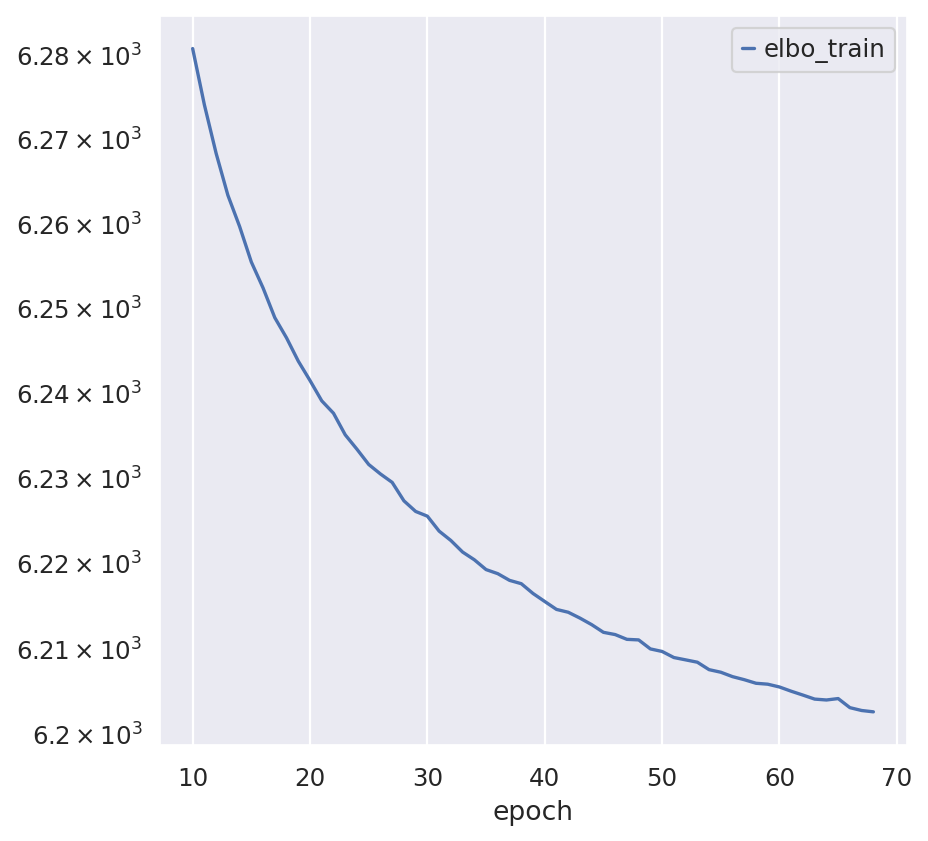

In [12]:
# Ensure convergence
train_test_results = model.history["elbo_train"]
# train_test_results["elbo_validation"] = model.history["elbo_validation"]
train_test_results.iloc[10:].plot(logy=True)  # exclude first 10 epochs
plt.show()

In [13]:
model.save("scvi_model_15", overwrite=True)

In [9]:
model = scvi.model.SCVI.load("scvi_model_15", adata=adata)

INFO     File scvi_model_15/model.pt already downloaded                                                            


In [10]:
SCVI_LATENT_KEY = "X_scVI"

latent = model.get_latent_representation()
adata.obsm[SCVI_LATENT_KEY] = latent
latent.shape

(115774, 15)

In [11]:
denoised = model.get_normalized_expression(adata, library_size=1e4)
denoised

Symbol,TSPAN6,DPM1,SCYL3,C1orf112,FGR,FUCA2,GCLC,NFYA,STPG1,NIPAL3,...,SEPSECS-AS1,LINC01144,ADORA3,BISPR,PRNCR1,LINC01481,CYB561D2,CCDC7,MATR3,RGS5
Cell_barcode,,,,,,,,,,,,,,,,,,,,,
T44_AAACCTGAGAGGTTGC.1,0.130337,0.138258,0.082470,0.024123,0.012230,0.105198,0.047015,0.022465,0.040509,0.130406,...,0.034031,0.018113,0.006514,0.004559,0.016226,0.330956,0.071342,0.013358,0.013944,6.579268
T44_AAACCTGAGAGTGAGA.1,0.112120,0.122054,0.067358,0.017463,0.012686,0.099557,0.049064,0.016803,0.046395,0.113780,...,0.022910,0.016279,0.007811,0.006094,0.016248,0.291313,0.064479,0.010919,0.017107,7.450483
T44_AAACCTGAGGCATGTG.1,0.134085,0.158980,0.072728,0.022068,0.012281,0.111294,0.036126,0.016892,0.039540,0.115483,...,0.035992,0.017094,0.007849,0.004978,0.015333,0.348068,0.081196,0.013003,0.013654,7.480272
T44_AAACCTGAGTGTACCT.1,0.149682,0.128030,0.056628,0.013956,0.011658,0.098183,0.038029,0.013321,0.040721,0.069319,...,0.015634,0.014254,0.012966,0.006621,0.010678,0.273732,0.087948,0.009523,0.013930,7.082599
T44_AAACCTGCAATGCCAT.1,0.114669,0.155136,0.070086,0.017834,0.011281,0.101517,0.057471,0.022116,0.038542,0.106538,...,0.022685,0.014488,0.007552,0.006441,0.012863,0.291663,0.093428,0.011174,0.013088,7.879576
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
T40_TTTGGTTAGCAATATG.1,0.123519,0.733093,0.060025,0.224028,0.045739,0.118671,0.046586,0.089832,0.020220,0.035707,...,0.055779,0.010382,0.017383,0.018784,0.018381,0.125545,0.075209,0.014896,0.014119,3.417658
T40_TTTGGTTAGTGGAGTC.1,0.139469,1.039490,0.052258,0.110625,0.052402,0.153310,0.025600,0.060162,0.019855,0.047027,...,0.071198,0.006772,0.023578,0.029483,0.011652,0.129523,0.097960,0.013590,0.017346,5.008021
T40_TTTGGTTCATAGTAAG.1,0.156502,0.442084,0.062471,0.066875,0.039068,0.121411,0.030892,0.025050,0.012659,0.057422,...,0.034528,0.009999,0.014425,0.020380,0.011284,0.181994,0.123199,0.012839,0.019849,4.827228


In [12]:
SCVI_NORMALIZED_KEY = "scvi_normalized"

adata.layers[SCVI_NORMALIZED_KEY] = model.get_normalized_expression(library_size=1e4)

In [13]:
# use scVI latent space for UMAP generation
sc.pp.neighbors(adata, n_neighbors=15, use_rep=SCVI_LATENT_KEY)
adata

AnnData object with n_obs × n_vars = 115774 × 12939
    obs: 'sample_ID', 'Gender', 'INSS_stage', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'doublet_score', 'predicted_doublet', 'cell_type', '_scvi_batch', '_scvi_labels'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'scrublet', 'hvg', '_scvi_uuid', '_scvi_manager_uuid', 'neighbors'
    obsm: '_scvi_extra_continuous_covs', 'X_scVI'
    layers: 'scvi_normalized'
    obsp: 'distances', 'connectivities'

In [14]:
# neighbors were already computed using scVI
SCVI_CLUSTERS_KEY = "leiden_scVI"
sc.tl.leiden(adata, key_added=SCVI_CLUSTERS_KEY, resolution=3)

/tmp/ipykernel_4023/3848131586.py:3: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, key_added=SCVI_CLUSTERS_KEY, resolution=3)


In [15]:
adata.obs.leiden_scVI

Cell_barcode
T44_AAACCTGAGAGGTTGC.1     2
T44_AAACCTGAGAGTGAGA.1     2
T44_AAACCTGAGGCATGTG.1     2
T44_AAACCTGAGTGTACCT.1    48
T44_AAACCTGCAATGCCAT.1     2
                          ..
T40_TTTGGTTAGCAATATG.1     7
T40_TTTGGTTAGTGGAGTC.1    24
T40_TTTGGTTCATAGTAAG.1    12
T40_TTTGTCAAGTCAATAG.1     7
T40_TTTGTCATCACTTATC.1    17
Name: leiden_scVI, Length: 115774, dtype: category
Categories (56, object): ['0', '1', '2', '3', ..., '52', '53', '54', '55']

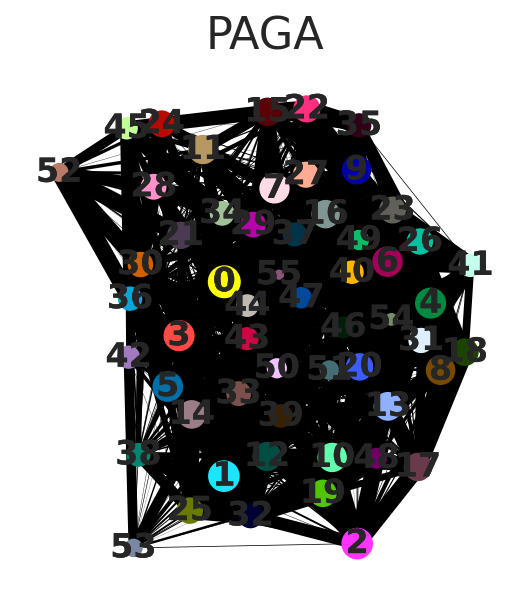

AnnData object with n_obs × n_vars = 115774 × 12939
    obs: 'sample_ID', 'Gender', 'INSS_stage', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'doublet_score', 'predicted_doublet', 'cell_type', '_scvi_batch', '_scvi_labels', 'leiden_scVI'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'scrublet', 'hvg', '_scvi_uuid', '_scvi_manager_uuid', 'neighbors', 'leiden_scVI', 'paga', 'leiden_scVI_sizes', 'leiden_scVI_colors'
    obsm: '_scvi_extra_continuous_covs', 'X_scVI'
    layers: 'scvi_normalized'
    obsp: 'distances', 'connectivities'

In [16]:
sc.tl.paga(adata, groups=SCVI_CLUSTERS_KEY)
sc.set_figure_params(fontsize=20)
sc.pl.paga(adata, fontsize=15, frameon=False, title='PAGA', fontoutline=0, save="_NE.svg")
adata

In [17]:
# sc.tl.umap(ndata)
sc.tl.umap(adata, init_pos='paga')
adata

AnnData object with n_obs × n_vars = 115774 × 12939
    obs: 'sample_ID', 'Gender', 'INSS_stage', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'doublet_score', 'predicted_doublet', 'cell_type', '_scvi_batch', '_scvi_labels', 'leiden_scVI'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'scrublet', 'hvg', '_scvi_uuid', '_scvi_manager_uuid', 'neighbors', 'leiden_scVI', 'paga', 'leiden_scVI_sizes', 'leiden_scVI_colors', 'umap'
    obsm: '_scvi_extra_continuous_covs', 'X_scVI', 'X_umap'
    layers: 'scvi_normalized'
    obsp: 'distances', 'connectivities'

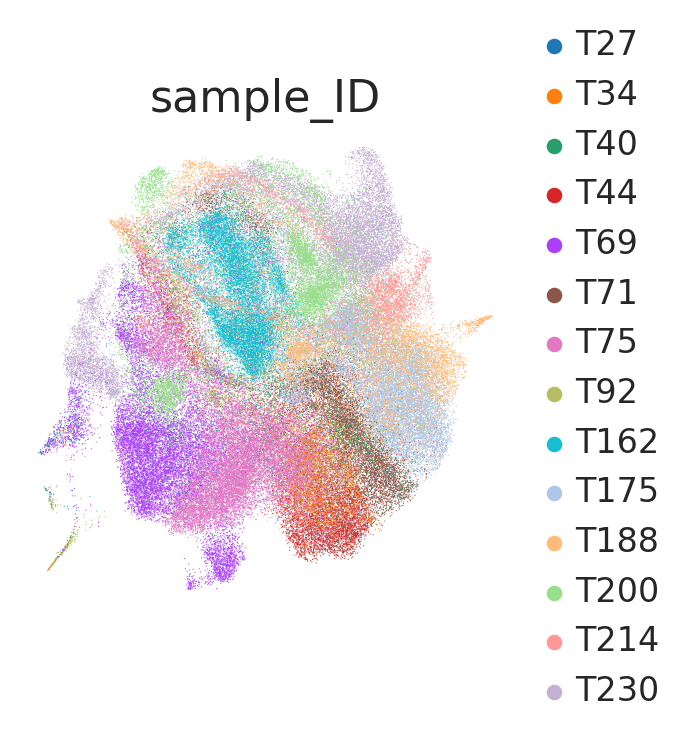

In [18]:
sc.pl.umap(adata, color='sample_ID', 
           frameon=False, legend_fontsize=15, legend_fontoutline=1, save="_NE_sample_ID.svg")

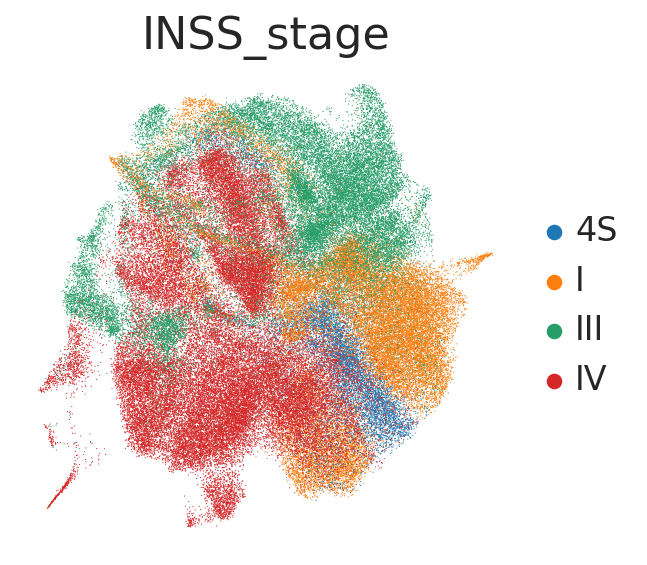

In [19]:
sc.pl.umap(adata, color='INSS_stage',
           frameon=False, legend_fontsize=15, legend_fontoutline=1, save="_NE_INSS.svg")

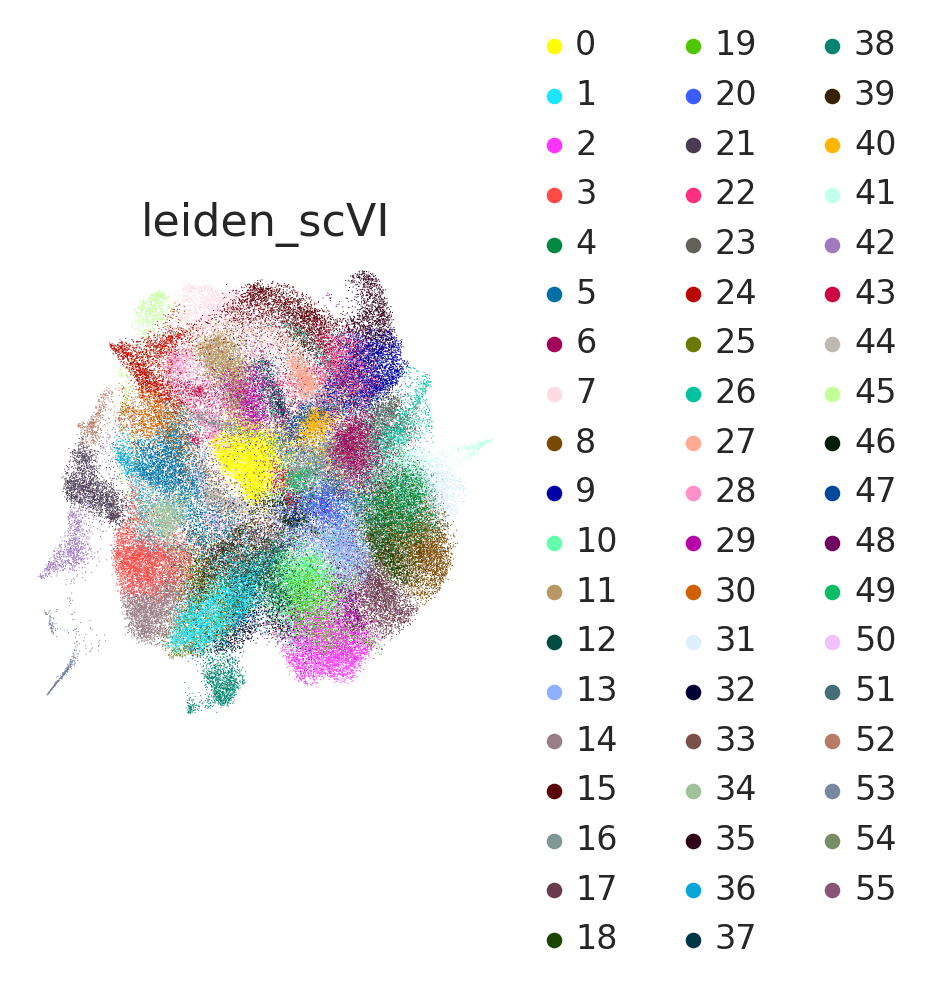

In [20]:
sc.pl.umap(adata, color=SCVI_CLUSTERS_KEY, frameon=False, legend_fontsize=15, save="_NE.svg")

In [21]:
adata

AnnData object with n_obs × n_vars = 115774 × 12939
    obs: 'sample_ID', 'Gender', 'INSS_stage', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'doublet_score', 'predicted_doublet', 'cell_type', '_scvi_batch', '_scvi_labels', 'leiden_scVI'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'scrublet', 'hvg', '_scvi_uuid', '_scvi_manager_uuid', 'neighbors', 'leiden_scVI', 'paga', 'leiden_scVI_sizes', 'leiden_scVI_colors', 'umap', 'sample_ID_colors', 'INSS_stage_colors'
    obsm: '_scvi_extra_continuous_covs', 'X_scVI', 'X_umap'
    layers: 'scvi_normalized'
    obsp: 'distances', 'connectivities'

In [22]:
# normalized data by library size
adata.write("NE_reclustered.h5ad")

In [23]:
adata = sc.read_h5ad("NE_reclustered.h5ad")

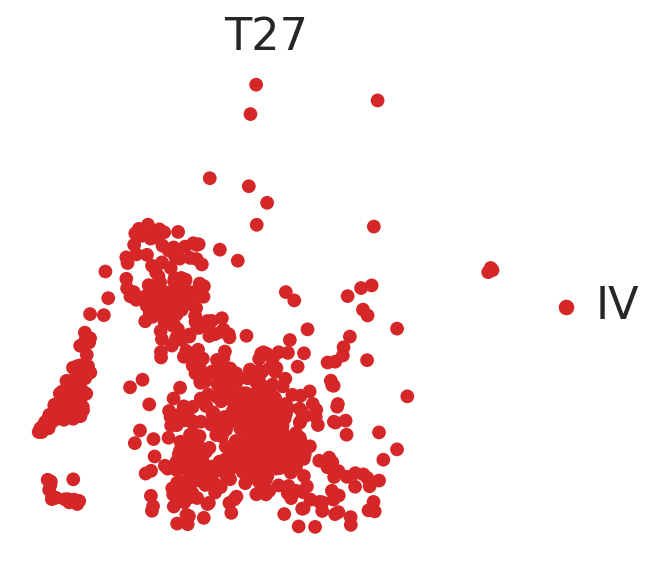

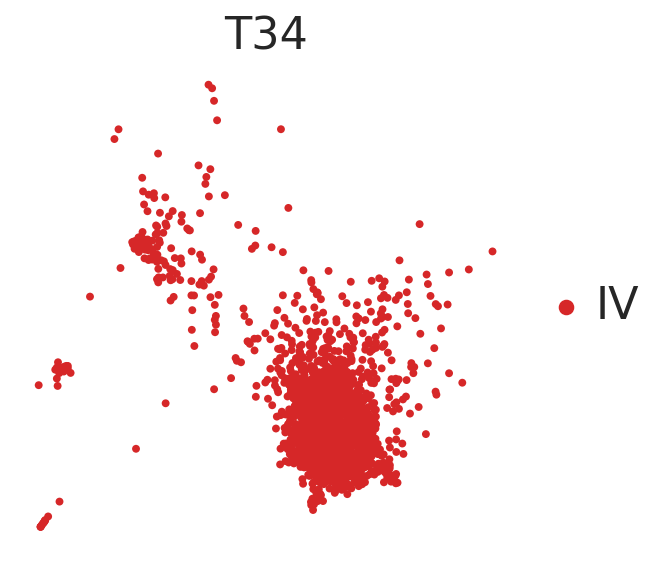

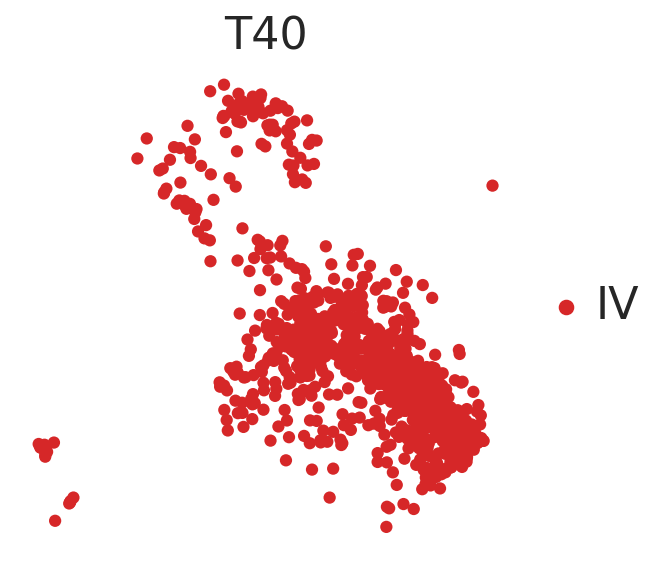

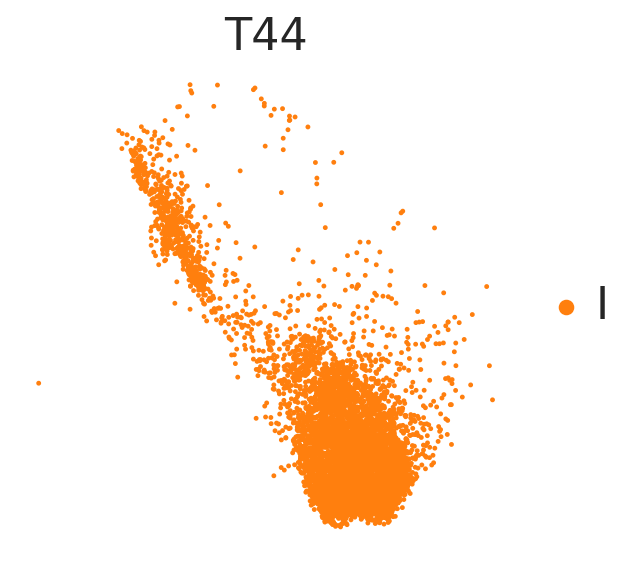

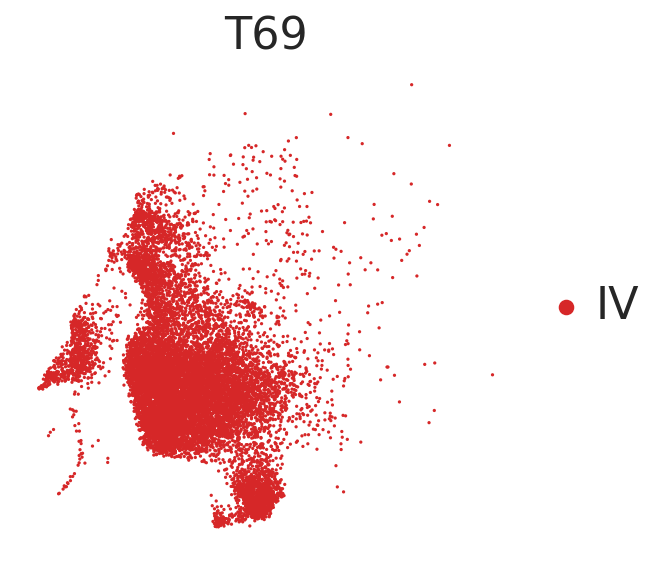

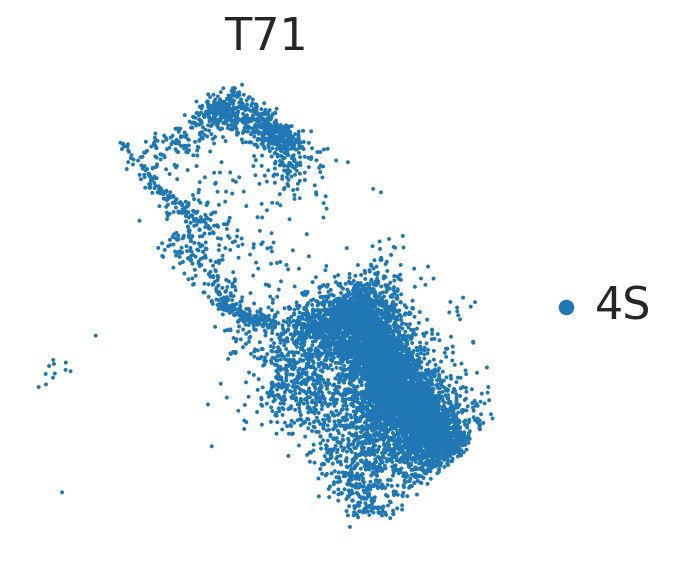

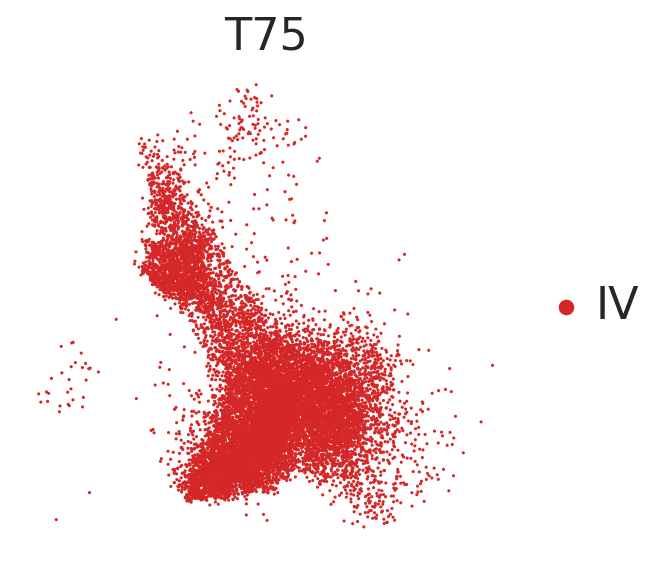

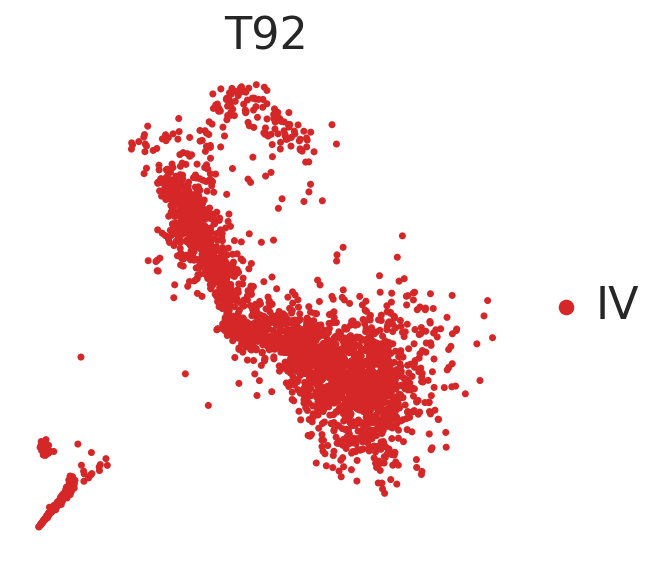

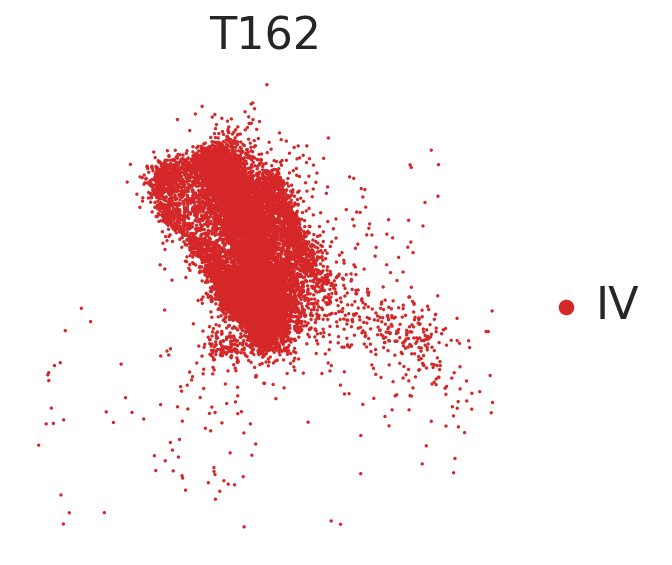

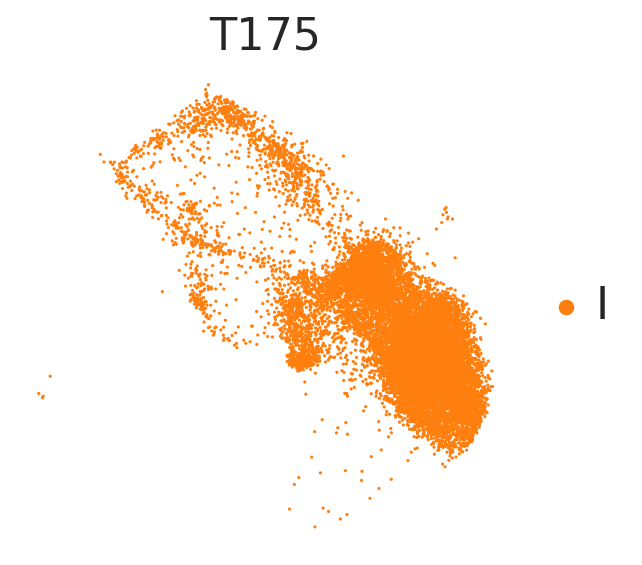

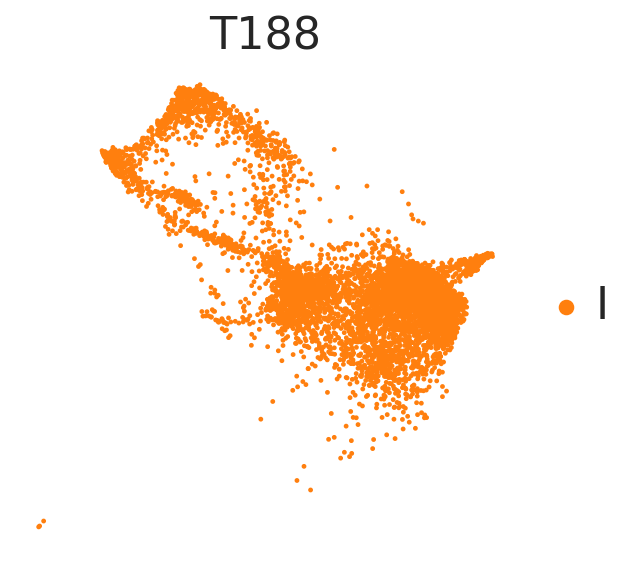

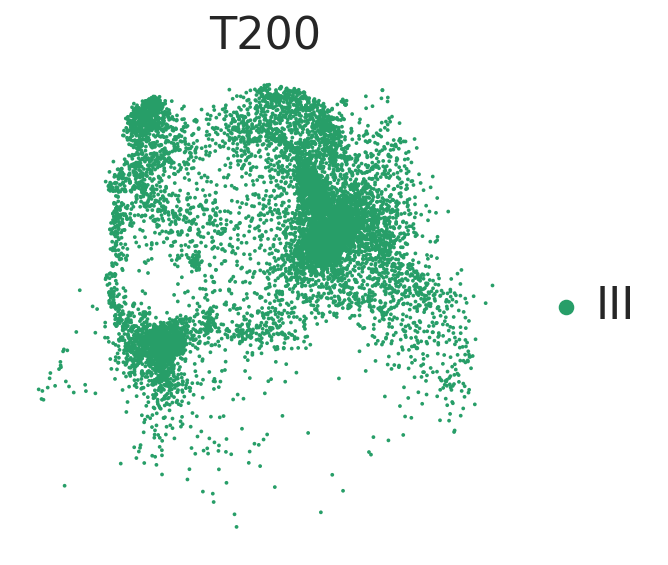

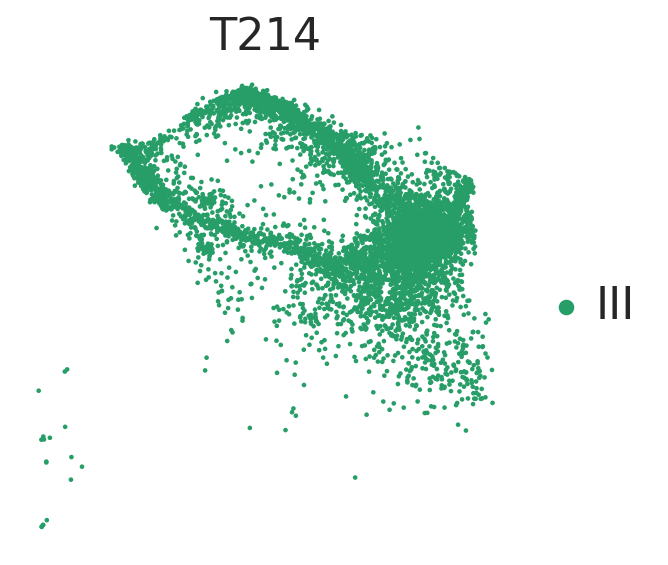

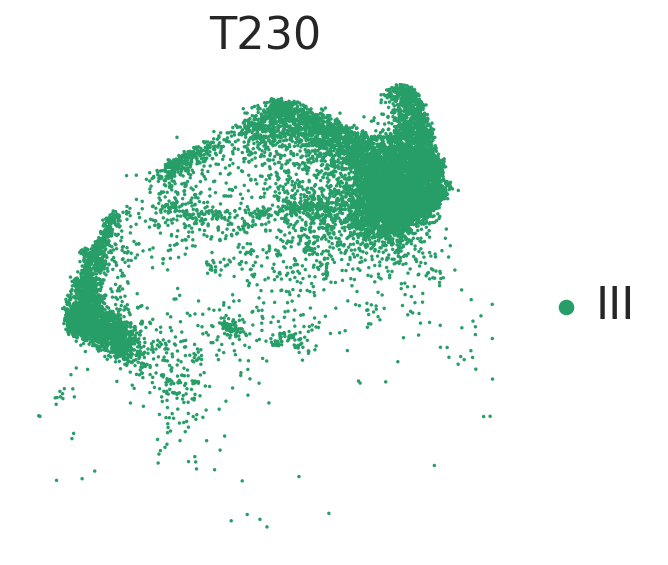

In [24]:
for i in ['T27', 'T34', 'T40', 'T44', 'T69', 'T71', 'T75', 'T92', 'T162', 'T175', 'T188', 'T200', 'T214', 'T230']:
    sc.pl.umap(adata[adata.obs.sample_ID==i], color='INSS_stage', frameon=False, legend_fontsize=20, legend_fontoutline=1, title=i, save=f"_{i}_INSS.svg")

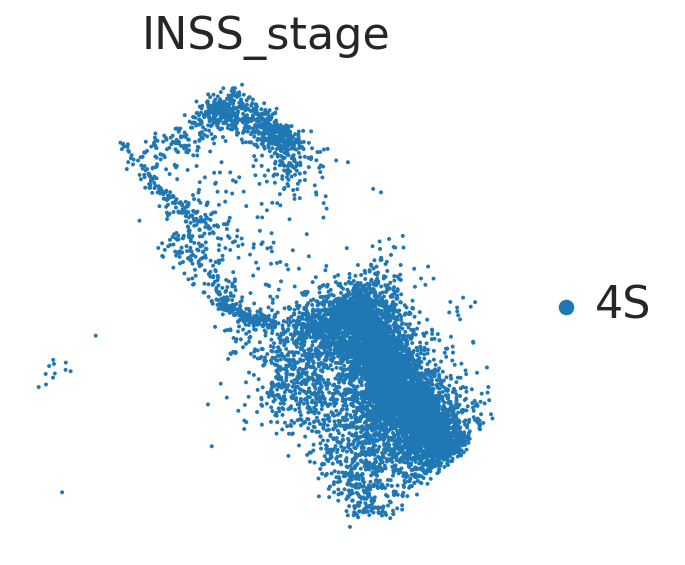

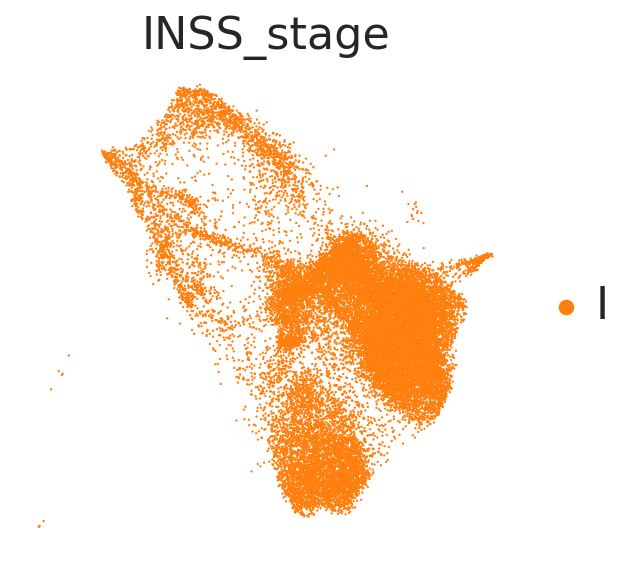

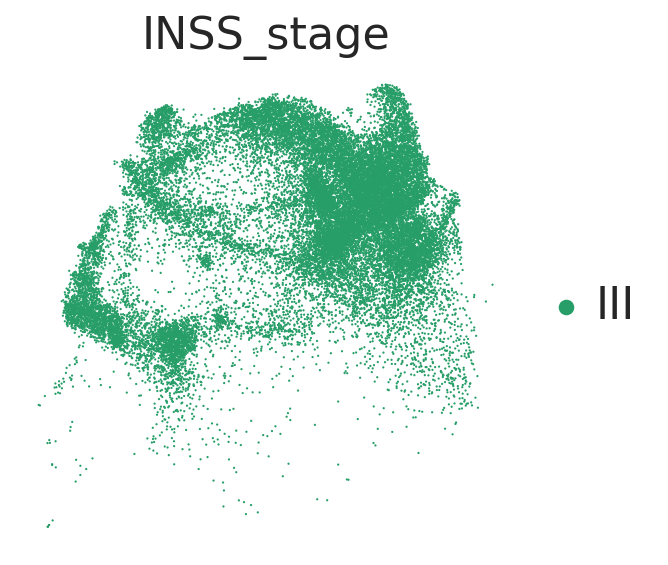

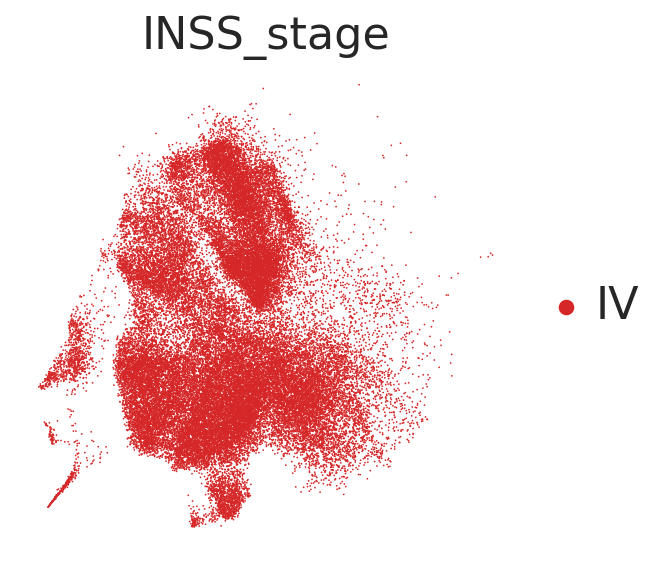

In [25]:
for i in ['4S', 'I', 'III', 'IV']:
    sc.pl.umap(adata[adata.obs.INSS_stage==i], color='INSS_stage', frameon=False, legend_fontsize=20, legend_fontoutline=1, save=f"_{i}_INSS.svg")

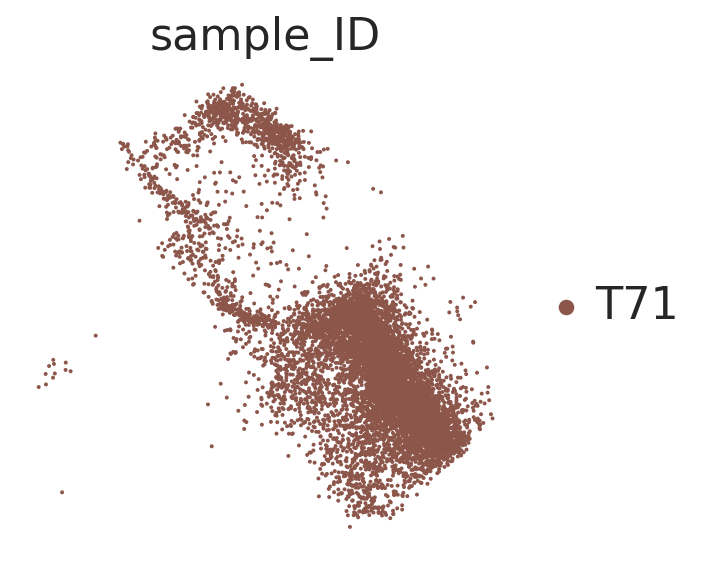

In [26]:
sc.pl.umap(adata[adata.obs.INSS_stage=='4S'], color='sample_ID', frameon=False, legend_fontsize=20, legend_fontoutline=1)

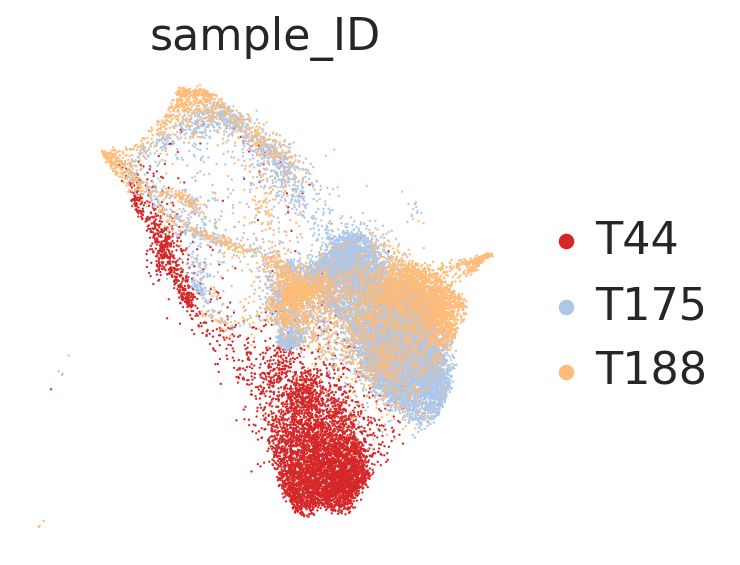

In [27]:
sc.pl.umap(adata[adata.obs.INSS_stage=='I'], color='sample_ID', frameon=False, legend_fontsize=20, legend_fontoutline=1)

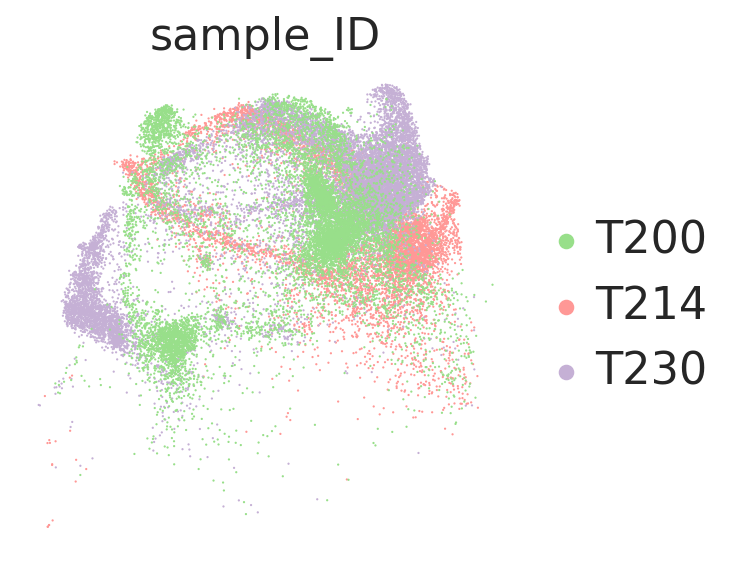

In [28]:
sc.pl.umap(adata[adata.obs.INSS_stage=='III'], color='sample_ID', frameon=False, legend_fontsize=20, legend_fontoutline=1)

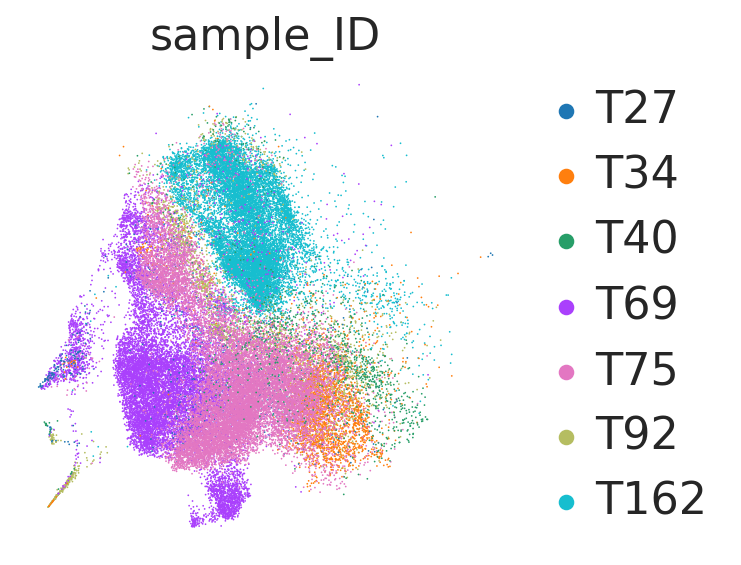

In [29]:
sc.pl.umap(adata[adata.obs.INSS_stage=='IV'], color='sample_ID', frameon=False, legend_fontsize=20, legend_fontoutline=1)